# Post-Merge Exploratory Data Analysis

## Career Compass Capstone Project

This notebook explores the merged Career Compass dataset created by combining O*NET occupational characteristics with Bureau of Labor Statistics (BLS) Occupational Employment and Wage Statistics (OEWS). The goal is to examine relationships between occupational characteristics, education, skills, and labor market outcomes that were not observable prior to merging the datasets.

In [1]:
import pandas as pd

master = pd.read_excel("career_compass_master.csv.xlsx")

master.head()

,onet_soc_code,soc_code,occupation_title,occupation_description,essential_skill_active_learning_im,essential_skill_active_learning_lv,essential_skill_active_listening_im,essential_skill_active_listening_lv,essential_skill_critical_thinking_im,essential_skill_critical_thinking_lv,...,hourly,bls_match,employment_log1p,annual_wage_spread_90_10,annual_wage_iqr,median_to_mean_wage_ratio,wage_data_available,median_wage_percentile,employment_percentile,labor_market_opportunity_score
0,11-1011.00,11-1011,Chief Executives,Determine and formulate policies and provide o...,3.75,4.50,4.00,4.75,4.38,4.75,...,NaN,True,12.227594,432030.0,226660.0,0.793643,True,0.970188,0.776795,0.873492
1,11-1011.03,11-1011,Chief Sustainability Officers,"Communicate and coordinate with management, sh...",3.75,3.88,4.00,4.00,4.12,4.12,...,NaN,True,12.227594,432030.0,226660.0,0.793643,True,0.970188,0.776795,0.873492
2,11-1021.00,11-1021,General and Operations Managers,"Plan, direct, or coordinate the operations of ...",3.62,3.75,4.00,4.12,3.88,3.88,...,NaN,True,15.069136,203300.0,94960.0,0.783830,True,0.828452,0.996878,0.912665
3,11-1031.00,11-1031,Legislators,"Develop, introduce, or enact laws and statutes...",NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,False,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN
4,11-2011.00,2011-11-01 00:00:00,Advertising and Promotions Managers,"Plan, direct, or coordinate advertising polici...",3.25,4.12,4.12,4.12,4.00,4.12,...,NaN,True,9.974458,222940.0,109680.0,0.866347,True,0.919456,0.314256,0.616856


In [2]:
# Dataset overview
print("Shape:", master.shape)

print("\nData Types:")
print(master.dtypes.head())

print("\nColumn Names:")
print(master.columns.tolist())

Shape: (1016, 408)

Data Types:
onet_soc_code                          object
soc_code                               object
occupation_title                       object
occupation_description                 object
essential_skill_active_learning_im    float64
dtype: object

Column Names:
['onet_soc_code', 'soc_code', 'occupation_title', 'occupation_description', 'essential_skill_active_learning_im', 'essential_skill_active_learning_lv', 'essential_skill_active_listening_im', 'essential_skill_active_listening_lv', 'essential_skill_critical_thinking_im', 'essential_skill_critical_thinking_lv', 'essential_skill_learning_strategies_im', 'essential_skill_learning_strategies_lv', 'essential_skill_mathematics_im', 'essential_skill_mathematics_lv', 'essential_skill_monitoring_im', 'essential_skill_monitoring_lv', 'essential_skill_reading_comprehension_im', 'essential_skill_reading_comprehension_lv', 'essential_skill_science_im', 'essential_skill_science_lv', 'essential_skill_speaking_im', 'e

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (8,5)

In [6]:
print("Dataset Shape:", master.shape)

master.info()

Dataset Shape: (1016, 408)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1016 entries, 0 to 1015
Columns: 408 entries, onet_soc_code to labor_market_opportunity_score
dtypes: bool(2), float64(400), object(6)
memory usage: 3.1+ MB


In [7]:
master.describe().T

,count,mean,std,min,25%,50%,75%,max
essential_skill_active_learning_im,894.0,3.117864,0.529039,1.880000,2.750000,3.120000,3.500000,4.250000
essential_skill_active_learning_lv,894.0,3.198546,0.780243,1.000000,2.620000,3.120000,3.880000,5.500000
essential_skill_active_listening_im,894.0,3.597461,0.460417,2.000000,3.120000,3.750000,4.000000,5.000000
essential_skill_active_listening_lv,894.0,3.555850,0.641941,2.000000,3.000000,3.750000,4.000000,5.880000
essential_skill_critical_thinking_im,894.0,3.518110,0.458730,2.250000,3.120000,3.620000,3.880000,4.880000
...,...,...,...,...,...,...,...,...
annual_wage_iqr,956.0,42137.656904,43593.854377,3940.000000,18350.000000,30825.000000,50240.000000,376570.000000
median_to_mean_wage_ratio,956.0,0.932265,0.060237,0.323552,0.903781,0.938917,0.964907,1.158396
median_wage_percentile,956.0,0.500523,0.288825,0.001046,0.251569,0.500523,0.750262,1.000000
employment_percentile,961.0,0.500520,0.288825,0.001041,0.250780,0.500520,0.750780,1.000000


The merged dataset contains 1,016 occupations and 408 variables. Variables include occupational characteristics from O*NET, labor market statistics from the BLS, and engineered features created during data preparation.

In [8]:
missing = (
    master.isnull()
          .sum()
          .sort_values(ascending=False)
          .to_frame("Missing Count")
)

missing["Percent Missing"] = (
    missing["Missing Count"] / len(master)
) * 100

missing.head(20)

,Missing Count,Percent Missing
hourly,1011,99.507874
annual,959,94.389764
knowledge_fine_arts_lv,561,55.216535
knowledge_food_production_lv,545,53.641732
knowledge_history_and_archeology_lv,489,48.129921
knowledge_philosophy_and_theology_lv,448,44.094488
knowledge_biology_lv,430,42.322835
knowledge_building_and_construction_lv,406,39.960630
knowledge_medicine_and_dentistry_lv,381,37.500000
knowledge_therapy_and_counseling_lv,373,36.712598


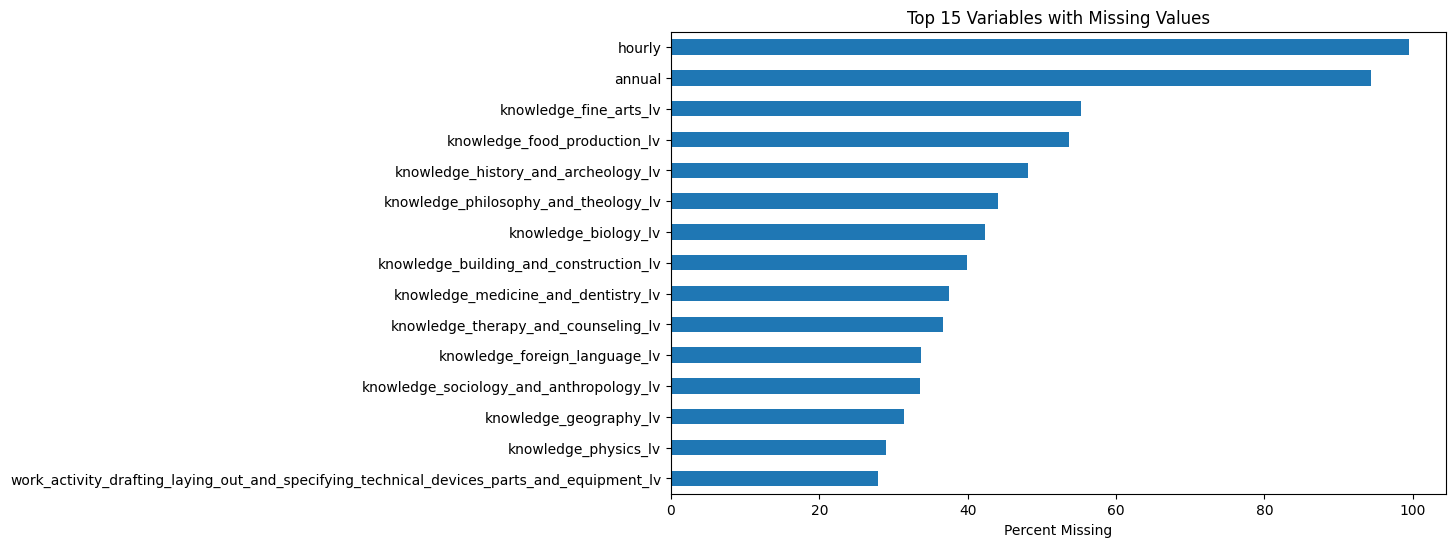

In [9]:
plt.figure(figsize=(10,6))

missing.head(15)["Percent Missing"].sort_values().plot(kind="barh")

plt.title("Top 15 Variables with Missing Values")
plt.xlabel("Percent Missing")

plt.show()

The merged dataset contains 1,016 occupations described by 408 variables derived from O*NET, BLS OEWS, and engineered features. Most variables are numeric, making the dataset well suited for quantitative analysis. Missing values are concentrated in a small number of variables. The hourly and annual indicator fields have the highest percentage of missing values because they are only populated for occupations reported exclusively in those units, while several specialized knowledge and work activity variables are missing for occupations where those attributes are not applicable.

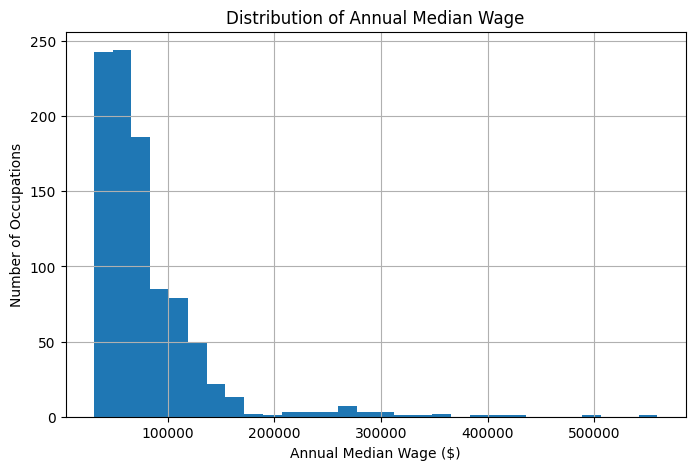

In [10]:
plt.figure(figsize=(8,5))

master["a_median"].dropna().hist(bins=30)

plt.title("Distribution of Annual Median Wage")
plt.xlabel("Annual Median Wage ($)")
plt.ylabel("Number of Occupations")

plt.show()

In [11]:
master["a_median"].describe()

,a_median
count,956.000000
mean,79674.225941
std,52870.582362
min,30890.000000
25%,48427.500000
50%,64950.000000
75%,95555.000000
max,559030.000000


The histogram shows that the distribution of annual median wages is positively (right) skewed. Most occupations have annual median wages between approximately 40 thousand dollars and 100 thousand dollars, while a relatively small number of occupations earn substantially higher salaries. These high-paying occupations create a long right tail extending beyond 500 thousand dollars.

The descriptive statistics support this observation. The median annual wage is 64,950 dollars, while the mean is higher at approximately 79,674 dollars, indicating that a small number of high-paying occupations pull the average upward. The wide range of wages (from 30,890 dollars to 559,030 dollars) also reflects considerable variation in earnings across occupations.

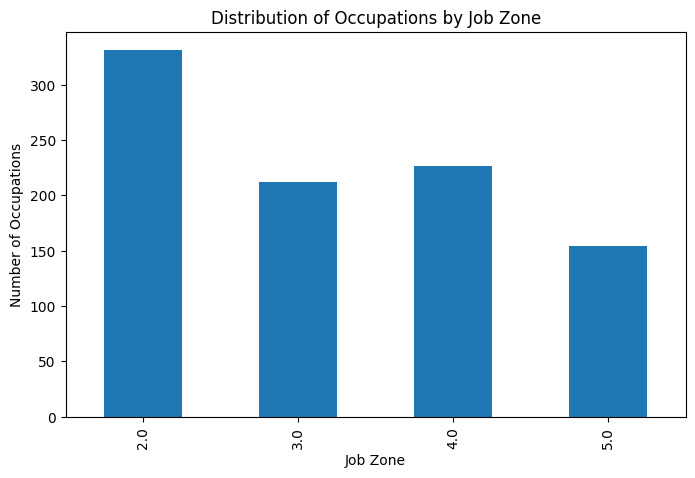

In [12]:
plt.figure(figsize=(8,5))

master["job_zone"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Distribution of Occupations by Job Zone")
plt.xlabel("Job Zone")
plt.ylabel("Number of Occupations")

plt.show()

In [13]:
master["job_zone"].value_counts().sort_index()

,count
job_zone,
2.0,331
3.0,212
4.0,226
5.0,154


<Figure size 900x600 with 0 Axes>

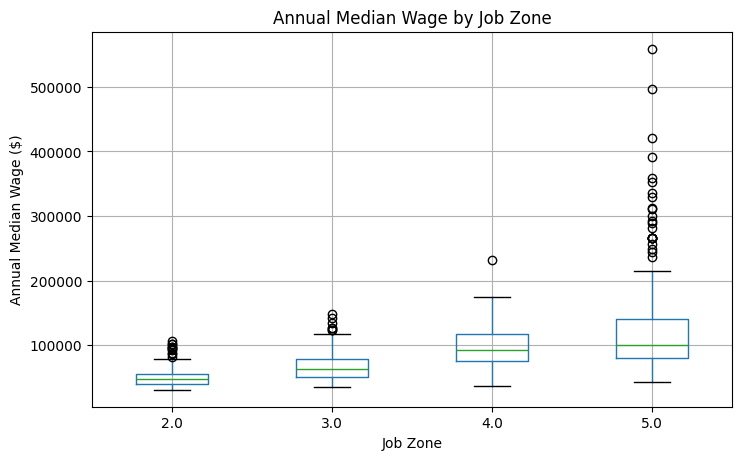

In [14]:
plt.figure(figsize=(9,6))

master.boxplot(
    column="a_median",
    by="job_zone"
)

plt.title("Annual Median Wage by Job Zone")
plt.suptitle("")

plt.xlabel("Job Zone")
plt.ylabel("Annual Median Wage ($)")

plt.show()

The bar chart shows that Job Zone 2 contains the largest number of occupations (331), followed by Job Zone 4 (226), Job Zone 3 (212), and Job Zone 5 (154). This suggests that occupations requiring relatively short to moderate preparation are the most common in the merged dataset, while occupations requiring extensive education and preparation (Job Zone 5) are less frequent.

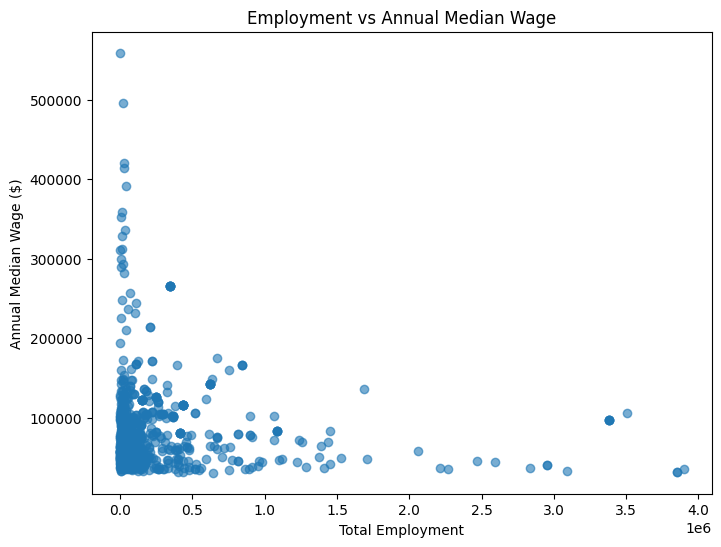

In [15]:
plt.figure(figsize=(8,6))

plt.scatter(
    master["tot_emp"],
    master["a_median"],
    alpha=0.6
)

plt.title("Employment vs Annual Median Wage")
plt.xlabel("Total Employment")
plt.ylabel("Annual Median Wage ($)")

plt.show()

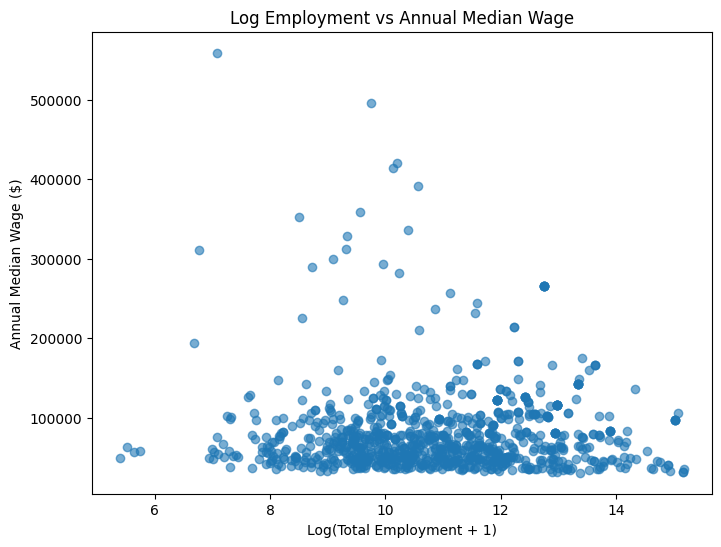

In [16]:
plt.figure(figsize=(8,6))

plt.scatter(
    master["employment_log1p"],
    master["a_median"],
    alpha=0.6
)

plt.title("Log Employment vs Annual Median Wage")
plt.xlabel("Log(Total Employment + 1)")
plt.ylabel("Annual Median Wage ($)")

plt.show()

The scatter plots suggest that there is not a strong linear relationship between employment and annual median wage. Occupations with very high employment exist across a wide range of salaries, while many of the highest-paying occupations tend to employ relatively fewer workers.

Using the logarithmic transformation of employment makes the relationship much easier to visualize by reducing the effect of extremely large employment values. Even after the transformation, there is no clear upward or downward trend, indicating that occupation demand alone does not determine wage levels. Instead, salary appears to be influenced by additional occupational characteristics such as education, required skills, and job complexity.

In [17]:
cols = [
    "a_median",
    "tot_emp",
    "job_zone",
    "education_expected_category",
    "essential_skill_importance_mean",
    "knowledge_importance_mean",
    "ability_importance_mean",
    "work_activity_importance_mean",
    "labor_market_opportunity_score"
]

master[cols].head()

,a_median,tot_emp,job_zone,education_expected_category,essential_skill_importance_mean,knowledge_importance_mean,ability_importance_mean,work_activity_importance_mean,labor_market_opportunity_score
0,213990.0,204350.0,5.0,7.2413,3.661,2.823939,2.404231,3.782927,0.873492
1,213990.0,204350.0,5.0,7.7037,3.612,2.771515,2.204615,3.522683,0.873492
2,105770.0,3503020.0,4.0,3.6732,3.412,2.421818,2.271731,3.489756,0.912665
3,NaN,NaN,4.0,NaN,NaN,NaN,NaN,NaN,NaN
4,133660.0,21470.0,4.0,5.2070,3.374,2.486364,2.243269,2.975122,0.616856


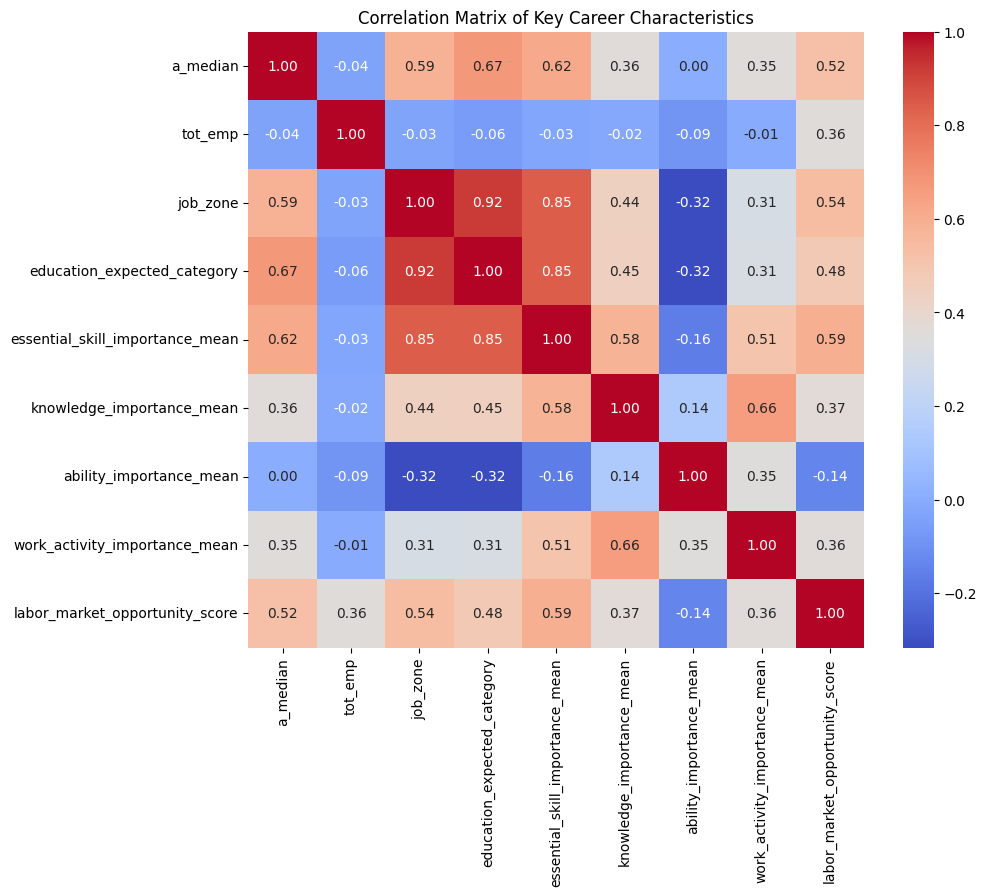

In [18]:
import seaborn as sns

corr = master[cols].corr(numeric_only=True)

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    square=True
)

plt.title("Correlation Matrix of Key Career Characteristics")

plt.show()

The correlation analysis revealed that annual median wage was most strongly associated with expected education level, essential skill importance, and Job Zone. Job Zone and expected education were highly correlated, reflecting the greater preparation requirements of higher-level occupations. Total employment showed almost no relationship with wages, indicating that widely available occupations are not necessarily better compensated. The labor market opportunity score was moderately associated with both wage and employment, consistent with its construction as a combined measure of these two factors.

In [19]:
top_wages = (
    master.loc[
        master["a_median"].notna(),
        ["occupation_title", "job_zone", "a_median", "tot_emp"]
    ]
    .sort_values("a_median", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

top_wages

,occupation_title,job_zone,a_median,tot_emp
0,Pediatric Surgeons,5.0,559030.0,1190.0
1,Cardiologists,5.0,496010.0,17290.0
2,Radiologists,5.0,420860.0,26770.0
3,"Surgeons, All Other",NaN,414010.0,25140.0
4,Anesthesiologists,5.0,391490.0,38760.0
5,"Orthopedic Surgeons, Except Pediatric",5.0,358550.0,14100.0
6,Oral and Maxillofacial Surgeons,5.0,352220.0,4910.0
7,Emergency Medicine Physicians,5.0,335550.0,32880.0
8,Dermatologists,5.0,328730.0,11370.0
9,"Physicians, Pathologists",5.0,312400.0,11110.0


In [20]:
top_opportunity = (
    master.loc[
        master["labor_market_opportunity_score"].notna(),
        [
            "occupation_title",
            "job_zone",
            "a_median",
            "tot_emp",
            "labor_market_opportunity_score"
        ]
    ]
    .sort_values("labor_market_opportunity_score", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

top_opportunity

,occupation_title,job_zone,a_median,tot_emp,labor_market_opportunity_score
0,Software Developers,4.0,135980.0,1687890.0,0.954027
1,Financial Managers,4.0,166570.0,841710.0,0.951499
2,Investment Fund Managers,5.0,166570.0,841710.0,0.951499
3,Treasurers and Controllers,4.0,166570.0,841710.0,0.951499
4,Computer and Information Systems Managers,4.0,175140.0,670570.0,0.949965
5,Lawyers,5.0,159670.0,754500.0,0.944724
6,Sales Managers,4.0,148270.0,637080.0,0.937429
7,Compliance Managers,4.0,141900.0,622190.0,0.930118
8,Brownfield Redevelopment Specialists and Site ...,4.0,141900.0,622190.0,0.930118
9,"Managers, All Other",NaN,141900.0,622190.0,0.930118
